In [1]:
import numpy as np
from tqdm import trange
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

---

В некоторой игре за выполнение эпического квеста игрок получает $6$ сундуков, из которых могут выпасть шлем, нагрудник или поножи. Каждый предмет выпадает равновероятно, т.е. с вероятностью $\frac{1}{3}$. Игрок получает полный сет, если у него есть каждый из этих предметов. Найдите вероятность получения полного сета после открытия всех сундуков.

Оцените вероятность с помощью 10000 испытаний.

In [2]:
epoches = 10000

success = 0

for epoch in tqdm(range(epoches)):
    s = set()

    for i in range(6):
        s.add(np.random.choice([1, 2, 3]))
    
    if len(s) == 3:
        success += 1

success / epoches

  0%|          | 0/10000 [00:00<?, ?it/s]

0.742

---

Максим печет печеньки и хочет украсить их кондитерской посыпкой. Известно, что когда он кидает горсть посыпки, она с вероятностью 90% попадает на противень. Если посыпка попала на противень, то с вероятностью 20% она попадет именно на ту печеньку, которую Максим задумал украсить. Максим бросил в сторону некоторой печеньки 10 горстей посыпки. С какой вероятностью после 10 бросков несчастная печенька останется без посыпки?

Оцените вероятность с помощью 10000 испытаний.

In [3]:
epoches = 10000

success = 0

for epoch in tqdm(range(epoches)):
    f = False
    for i in range(10):
        if np.random.rand() <= 0.9:
            if np.random.rand() <= 0.2:
                f = True
            else:
                pass
        else:
            pass
    if not f:
        success += 1

success / epoches

  0%|          | 0/10000 [00:00<?, ?it/s]

0.1366

---

Мотя разработал умную камеру, которая по росту взрослого человека определяет его пол: если человек выше 170 см, то она относит его к мужчинам, а если ниже, то к женщинам. Известно, что вероятность того, что случайный мужчина окажется выше 170 см, равна 75%, а вероятность того, что случайная женщина окажется выше 170 см, равна 8%. Известно также, что в исследуемом обществе на одну женщину приходится 0.86 мужчин.

Чему равна вероятность, что умная камера правильно определит пол случайного человека?

Оцените вероятность с помощью 10000 испытаний.

In [4]:
epoches = 10000

female_pr = 100 / 186
success = 0
for epoch in tqdm(range(epoches)):
    is_male = np.random.rand() <= female_pr

    is_tall = False
    if is_male:
        is_tall = (np.random.rand() <= 0.75)
    else:
        is_tall = (np.random.rand() <= 0.08)
    
    success += is_tall == is_male

success / epoches


  0%|          | 0/10000 [00:00<?, ?it/s]

0.8307

---

В графе на 10 вершинах каждое из 45 ребер независимо от остальных провели с вероятностью 1/3. С какой вероятностью получился связный граф?

In [5]:
epoches = 10000

def check(A: np.array):
    used = [0] * A.shape[0]

    def DFS(v):
        if used[v]:
            return
        
        used[v] = True

        for u in range(A.shape[1]):
            if A[v][u]:
                DFS(u)
    

    DFS(0)

    return sum(used) == A.shape[0]


success = 0
for epoch in tqdm(range(epoches)):
    A = np.random.rand(10, 10) <= 1/3

    for i in range(A.shape[0]):
        for j in range(i + 1, A.shape[1]):
            A[j][i] = A[i][j]
    
    success += check(A)

success / epoches

  0%|          | 0/10000 [00:00<?, ?it/s]

0.7588

---

Из земли растет ствол случайного дерева. С вероятностью 1 он расходится на две ветки, а с вероятностью 0 заканчивается грушей. Каждая из этих веток независимо с вероятностью 1/2 расходится на две ветки, а с вероятностью 1/2 заканчивается грушей. Каждая ветка на уровне kk (ствол это уровень 1) с вероятностью 1/k расходится на две ветки, а с вероятностью 1 − 1/k заканчивается грушей.

С какой вероятностью случайное дерево будет иметь высоту хотя бы 5? Иначе говоря, с какой вероятностью в этом дереве будет хотя бы одна ветка на уровне 5?

In [6]:
def tree_grow(k = 1):
    is_end = np.random.choice([0, 1], p=[1/k, 1 - 1/k])

    if is_end or k >= 5:
        return k
    
    l = tree_grow(k + 1)
    r = tree_grow(k + 1)

    return max(l, r)

epoches = 10000

success = 0
for epoch in tqdm(range(epoches)):
    if tree_grow() >= 5:
        success += 1

success / epoches

  0%|          | 0/10000 [00:00<?, ?it/s]

0.2437

---

В единичном квадрате случайно выбирают точку. С какой вероятностью расстояние между ней и нулем будет меньше 1?

In [7]:
epoches = 10000

success = 0
for epoch in tqdm(range(epoches)):
    success += (np.random.rand(2)**2).sum() < 1

success / epoches

  0%|          | 0/10000 [00:00<?, ?it/s]

np.float64(0.7869)

---

На отрезке случайно выбрали 3 точки и сделали в них разрезы. Оцените вероятность, с которой из получившихся кусков можно сложить четырехугольник.

In [8]:
np.sort(np.random.rand(3))

array([0.68745972, 0.74621596, 0.91890381])

In [9]:
epoches = 10000

success = 0
for epoch in tqdm(range(epoches)):
    points = np.sort(np.random.rand(3))
    lengths = []
    l_p = 0

    for p in points:
        lengths += [p - l_p]
        l_p = p
    lengths += [1 - l_p]
    lengths = np.sort(lengths)

    if sum(lengths[:3]) > lengths[-1]:
        success += 1

success / epoches

  0%|          | 0/10000 [00:00<?, ?it/s]

0.4975

In [10]:
if np.isclose(0.1, 0.100003):
    print("treu")

---

Оцените долю простых чисел от 1 до $10^{12}$

In [11]:
epoches = 10000

def is_prime(num):
    i = 2
    while i * i < num:
        if num % i == 0:
            return False
        num += 1
    
    return True

success = 0
for epoch in tqdm(range(epoches)):
    num = np.random.randint(1, int(1e12))

    if is_prime(num):
        success += 1

success / epoches

  0%|          | 0/10000 [00:00<?, ?it/s]

0.0

---

На шоссе длиной 1000 км независимо и равномерно припарковали 1000 машин каршеринга. Вася вышел из дома, который располагается точно у отметки 500 км и пошел вправо до ближайшей машины. Нарисуйте гистограмму расстояний до ближайшей вправо машины.

Предположим, что он уже прошел один километр и так и не встретил ни одной машины. Нарисуйте гистограмму расстояний от его текущего положения до ближайшей вправо машины в этом случае.

Попробуйте объяснить увиденное.

0.001
0.001


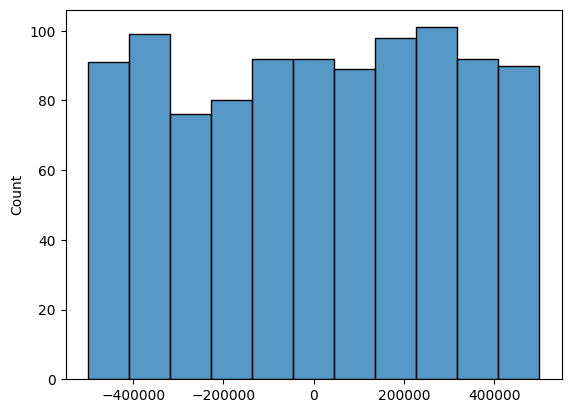

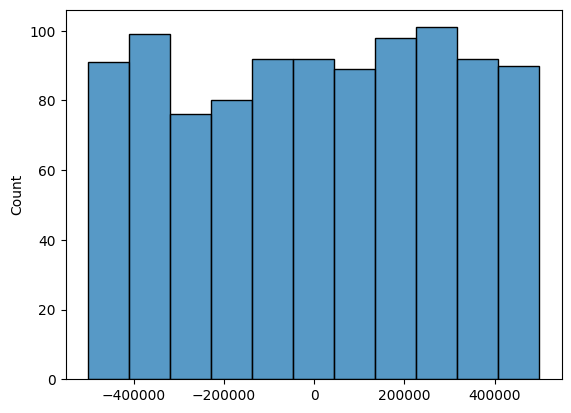

In [ ]:
road_length = 1000 * 1000 # meters
cars_num = 1000

cars = np.random.rand(cars_num) * road_length

print((((road_length / 2) <= cars) & (cars <= (road_length / 2 + 1000))).sum() / 1000)
print((((road_length / 2 + 1000) <= cars) & (cars <= (road_length / 2 + 2000))).sum() / 1000)


# sns.histplot(cars - road_length / 2)
# plt.show()

# sns.histplot(cars - road_length / 2 - 1000)
# plt.show()

---

In [13]:
epoches = 100_000

a = 0
s = 0

for epoch in trange(epoches):
    is_ill = np.random.rand() <= 0.02
    is_pos = np.random.rand() <= 0.99 if is_ill else np.random.rand() <= 0.01

    if is_pos:
        a += 1
        if is_ill:
            s += 1

s / a

100%|██████████| 100000/100000 [00:00<00:00, 1534946.97it/s]


0.658407664354146

In [14]:
epoches = 10_000

p1e = 0
p2e = 0
p12e = 0

for epoch in trange(epoches):
    p = np.random.choice([0.25, 0.75])
    
    p1 = np.random.rand() <= p
    p2 = np.random.rand() <= p

    p1e += p1
    p2e += p2
    if p1 and p2:
        p12e += 1

p1e * p2e / epoches**2, p12e / epoches

100%|██████████| 10000/10000 [00:00<00:00, 153413.85it/s]


(np.float64(0.2477052), 0.312)

---

In [15]:
epoches = 10_000

exp1 = dict()
exp2 = dict()

for epoch in trange(epoches):
    l = -1
    cur = -1
    steps = 0
    while True:
        steps += 1
        cur = np.random.rand() <= 0.5
        if l == 1 and cur == 0:
            break
        l = cur
    
    if not exp1.get(steps, False):
        exp1[steps] = 0
    exp1[steps] += 1

    l = -1
    cur = -1
    steps = 0
    while True:
        steps += 1
        cur = np.random.rand() <= 0.5
        if l == 1 and cur == 1:
            break
        l = cur
    
    if not exp2.get(steps, False):
        exp2[steps] = 0
    exp2[steps] += 1

for i in range(2, 7):
    print(exp1.get(i, 0) / epoches, end=' ')
print()
for i in range(2, 7):
    print(exp2.get(i, 0) / epoches, end=' ')

100%|██████████| 10000/10000 [00:00<00:00, 185116.05it/s]

0.2519 0.2516 0.1863 0.1299 0.0769 
0.2465 0.1238 0.1256 0.0934 0.081 

---

In [19]:
epoches = 10_00000

s = 0
for epoch in trange(epoches):
    t = np.random.randint(19 * 60, 20 * 60 + 1)
    m = np.random.randint(19 * 60, 20 * 60 + 1)

    if abs(t - m) <= 15:
        s += 1

s / epoches

100%|██████████| 1000000/1000000 [00:01<00:00, 525428.71it/s]


0.443518